# Subsampled Synthetic Graph EDA

Analyses BiGG runs trained with `--subsample`. Each run produces a directory of `subgraph_N` files.
This notebook examines:
1. Per-subgraph topology (size, density, degree distribution) — checks the K-cap is working
2. Combined graph vs original — same structural and feature fidelity as the standard EDA

In [18]:
import os
import dgl
from dgl import load_graphs
import networkx as nx
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [26]:
# Config
ORG_DATASET = "tolokers"
TASK = "hidden_labels"
# Subsampled run directory — same as SUBDIR in eda.ipynb, but points directly
# to the run directory (the one containing subgraph_* files), not a parent folder.
# Example: "blksize_-1_b_1_lr_0.001_epochs_50_..._sub6_size2000_k10"
RUN_NAME = "blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_binfeat_vae16_kl0.0_sub15_size500_p0.7"   # None = auto-select first subsampled run found in the task folder

# What to compare the synthetic subgraphs against:
#   'training_subsamples' — the real subgraphs used to train this run (fair apples-to-apples)
#   'full_original'       — the full original graph (legacy, unfair on structure)
COMPARE_AGAINST = 'training_subsamples'


## Locate Run & Load Real Comparison Data

If `COMPARE_AGAINST='training_subsamples'`, load the real subgraphs produced by forest-fire subsampling during training (saved alongside the synthetic outputs). Otherwise load the full original graph.

In [27]:
import warnings

task_path = f'../datasets/synthetic/bigg/{ORG_DATASET}/{TASK}'

run = RUN_NAME if RUN_NAME else sorted(
    f for f in os.listdir(task_path)
    if os.path.isdir(os.path.join(task_path, f))
    and any(x.startswith('subgraph_') for x in os.listdir(os.path.join(task_path, f)))
)[0]
run_path = os.path.join(task_path, run)
print(f"Analysing: {run}")

real_subgraphs = None  # only populated for 'training_subsamples' mode

if COMPARE_AGAINST == 'training_subsamples':
    train_dir = os.path.join(run_path, 'training_subsamples')
    if not os.path.isdir(train_dir):
        warnings.warn(
            f"'{train_dir}' not found — run predates the training-subsample persistence fix. "
            "Falling back to 'full_original'."
        )
        COMPARE_AGAINST = 'full_original'
    else:
        train_files = sorted(
            f for f in os.listdir(train_dir) if f.startswith('subgraph_')
        )
        real_subgraphs = []
        for fname in train_files:
            gs, _ = load_graphs(os.path.join(train_dir, fname))
            real_subgraphs.append(gs[0])
        real_combined = dgl.batch(real_subgraphs)
        print(f"Real training subsamples: {len(real_subgraphs)} subgraphs → "
              f"combined: {real_combined.num_nodes()} nodes, {real_combined.num_edges()} edges")

if COMPARE_AGAINST == 'full_original':
    real_combined, _ = load_graphs(f'../datasets/original/{ORG_DATASET}')
    real_combined = real_combined[0]
    print(f"Full original: {real_combined.num_nodes()} nodes, {real_combined.num_edges()} edges")

print(f"Anomalies in real comparison graph: {real_combined.ndata['label'].tolist().count(1)}")


Analysing: blksize_-1_b_1_lr_0.0003_epochs_300_noise_0.3_ss_0.3_norm_cdf_bfs_lw_0.01_0.1_det_masked_binfeat_vae16_kl0.0_sub15_size500_p0.7
Real training subsamples: 15 subgraphs → combined: 7500 nodes, 653614 edges
Anomalies in real comparison graph: 2106


## Load Subgraphs

In [28]:
subgraph_files = sorted(
    f for f in os.listdir(run_path) if f.startswith('subgraph_')
)

subgraphs = []
for fname in subgraph_files:
    gs, _ = load_graphs(os.path.join(run_path, fname))
    subgraphs.append(gs[0])

combined = dgl.batch(subgraphs)
print(f"Loaded {len(subgraphs)} subgraphs → combined: {combined.num_nodes()} nodes, {combined.num_edges()} edges")

# Load norm stats if present
norm_stats = None
stats_path = os.path.join(run_path, 'norm_stats.pt')
if os.path.exists(stats_path):
    norm_stats = torch.load(stats_path, weights_only=False)
    print(f"Norm stats loaded: method={norm_stats['method']}")

Loaded 15 subgraphs → combined: 7500 nodes, 493154 edges
Norm stats loaded: method=cdf


## Per-Subgraph Summary

In [29]:
rows = []
for i, (fname, sg) in enumerate(zip(subgraph_files, subgraphs)):
    n = sg.num_nodes()
    e = sg.num_edges()
    anom = sg.ndata['label'].tolist().count(1) if 'label' in sg.ndata else 'N/A'
    density = e / (n * (n - 1)) if n > 1 else 0.0
    max_possible_edges = n * (n - 1) / 2
    rows.append({
        'Subgraph': fname,
        'Nodes': n,
        'Edges': e,
        'Anomalies': anom,
        'Density': f'{density:.5f}',
        'Edges / max possible': f'{e / max_possible_edges:.5f}',
    })

# Add combined synthetic and real comparison rows
cn = combined.num_nodes(); ce = combined.num_edges()
rn = real_combined.num_nodes(); re_ = real_combined.num_edges()
rows.append({'Subgraph': '--- COMBINED SYN ---', 'Nodes': cn, 'Edges': ce,
             'Anomalies': combined.ndata['label'].tolist().count(1) if 'label' in combined.ndata else 'N/A',
             'Density': f'{ce / (cn*(cn-1)):.5f}', 'Edges / max possible': ''})
real_label = 'REAL (TRAIN SUBSAMPLES)' if COMPARE_AGAINST == 'training_subsamples' else 'REAL (FULL ORIGINAL)'
rows.append({'Subgraph': f'--- {real_label} ---', 'Nodes': rn, 'Edges': re_,
             'Anomalies': real_combined.ndata['label'].tolist().count(1),
             'Density': f'{re_ / (rn*(rn-1)):.5f}', 'Edges / max possible': ''})

display(pd.DataFrame(rows).set_index('Subgraph'))

,Nodes,Edges,Anomalies,Density,Edges / max possible
Subgraph,,,,,
subgraph_0,500,34450,42,0.13808,0.27615
subgraph_1,500,26798,34,0.10741,0.21481
subgraph_10,500,29638,33,0.11879,0.23758
subgraph_11,500,25634,24,0.10274,0.20548
subgraph_12,500,29442,36,0.11800,0.23601
subgraph_13,500,28268,16,0.11330,0.22660
subgraph_14,500,31614,36,0.12671,0.25342
subgraph_2,500,46780,187,0.18749,0.37499
subgraph_3,500,42512,137,0.17039,0.34078


## Per-Subgraph Degree Distribution

The K-neighbor cap should bound each subgraph's max degree to ≈ `subsample_k` (for nodes near the BFS frontier). The distribution should be narrow and low compared to the original's power-law tail.

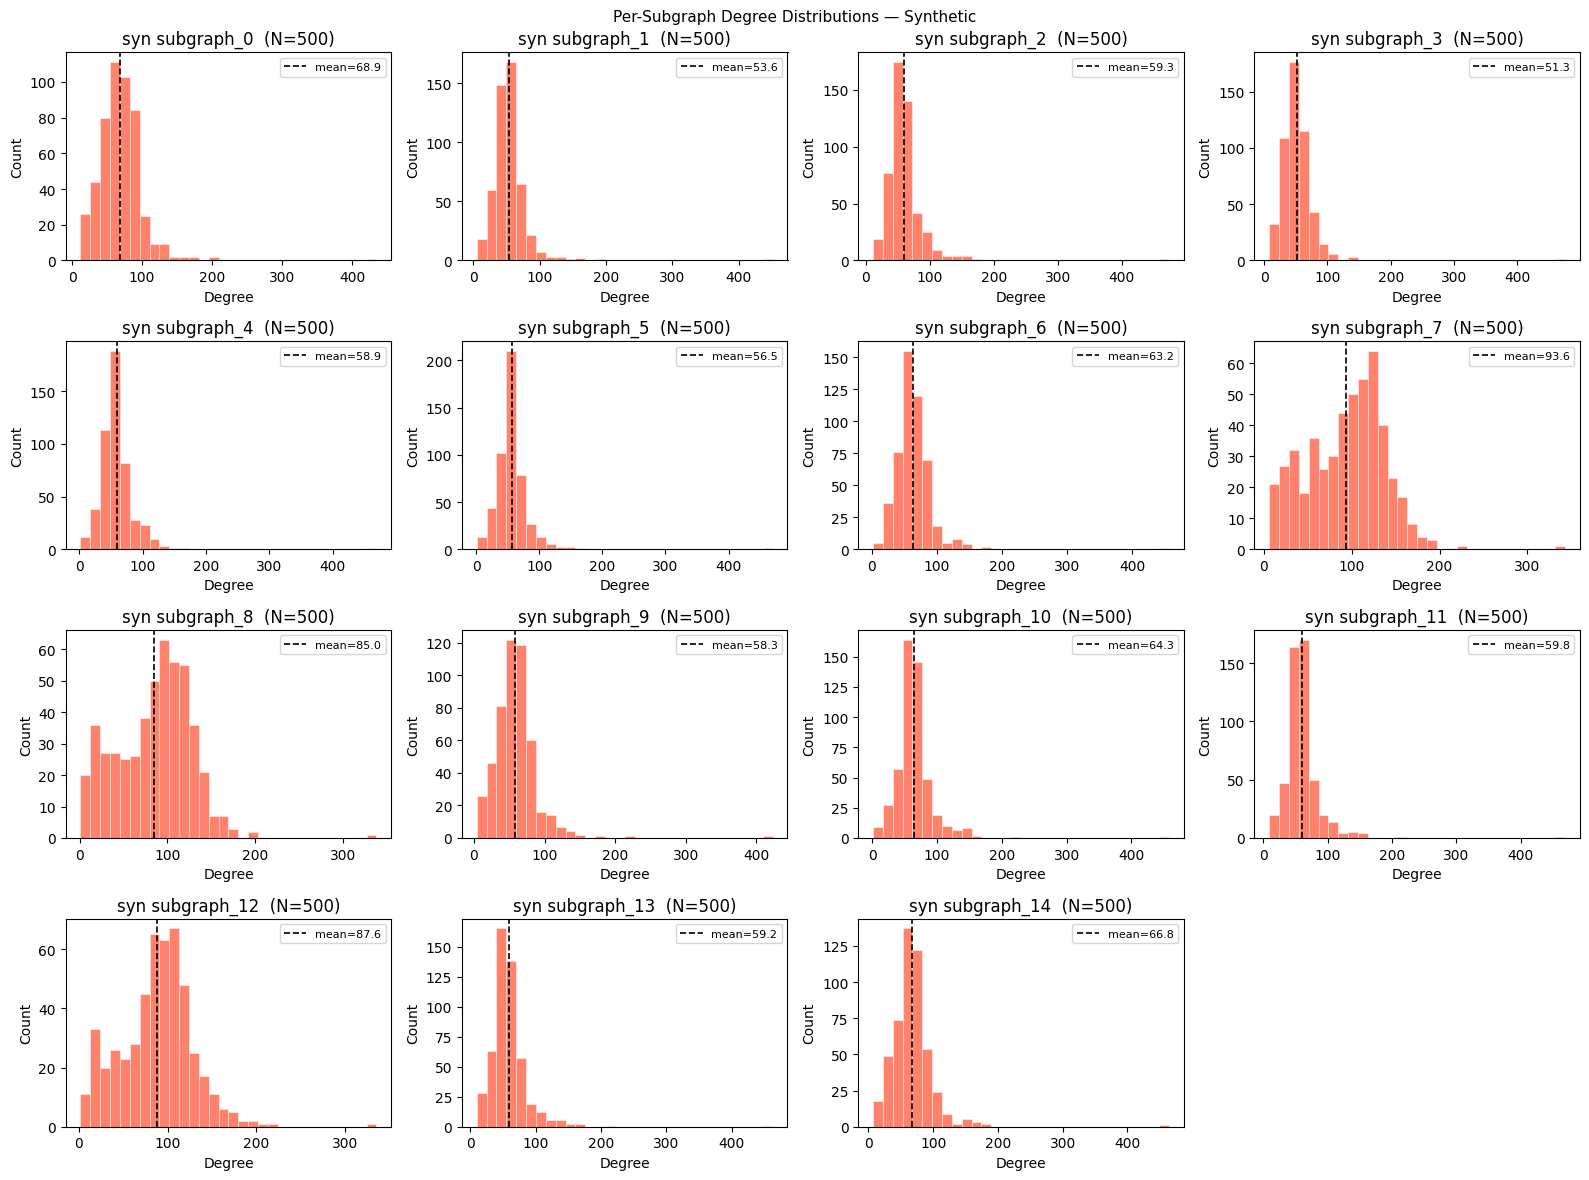

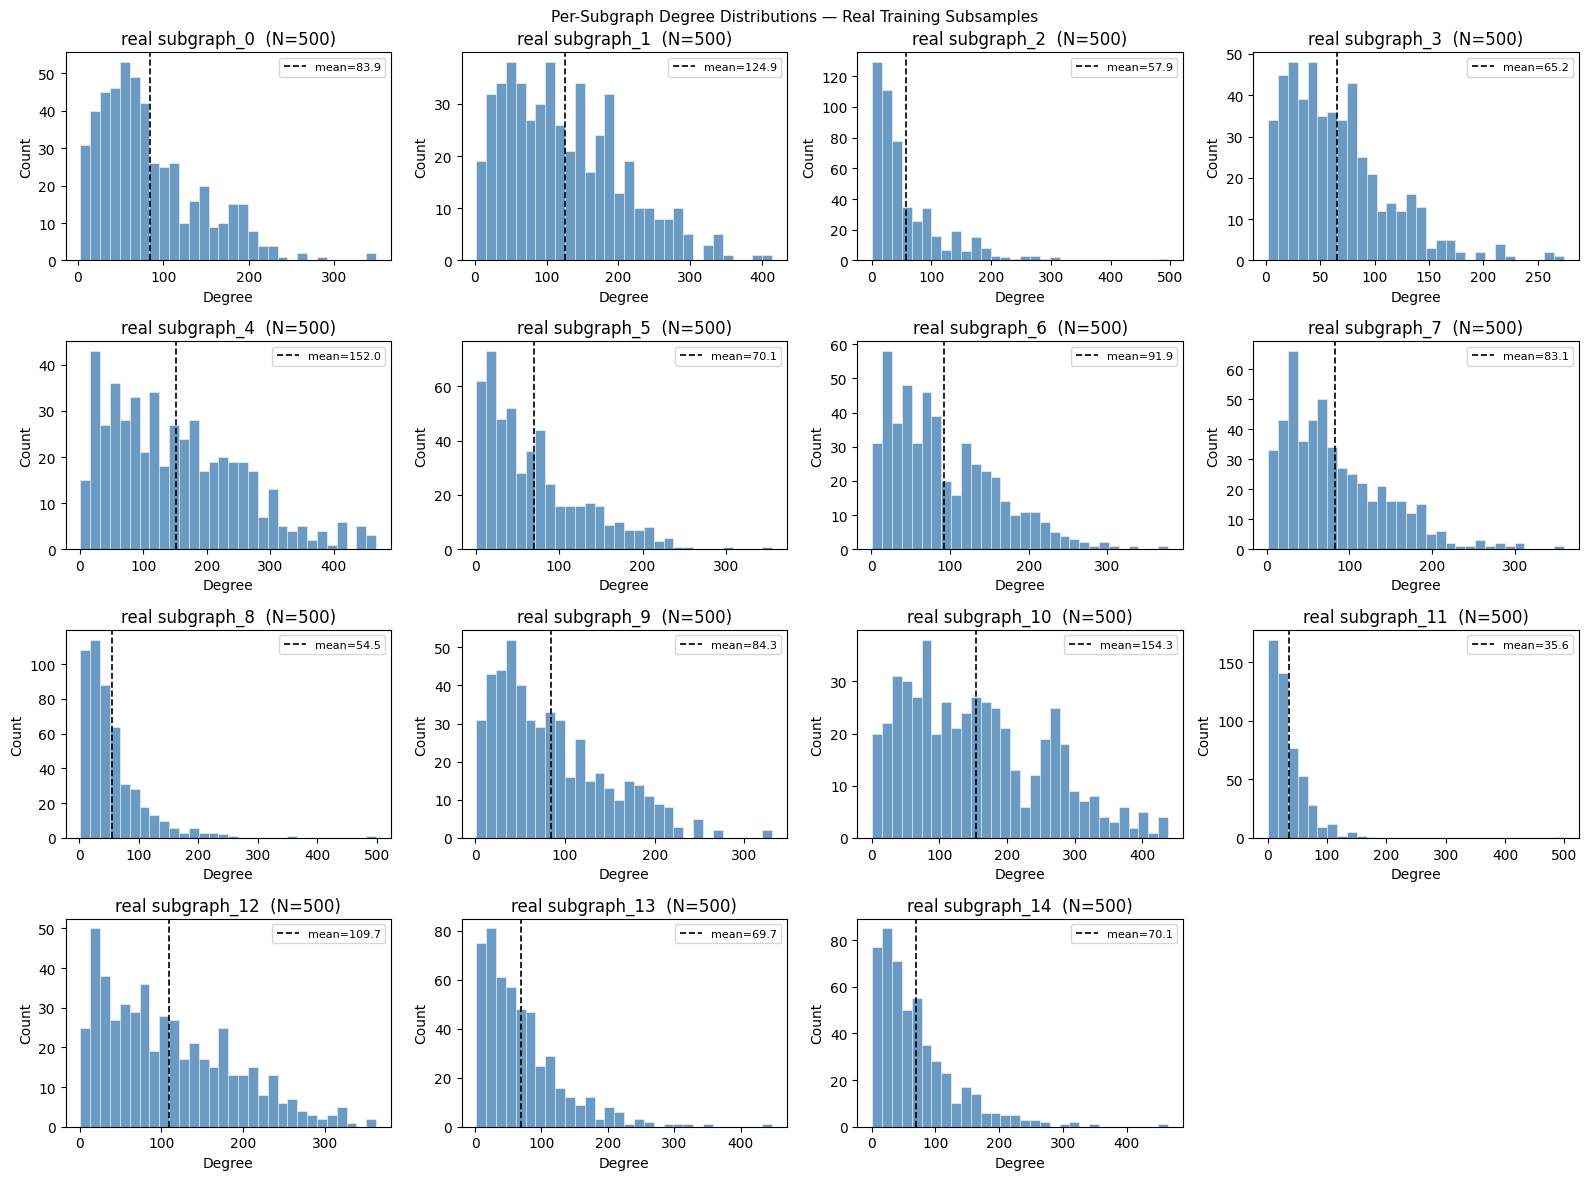

Real comparison graph — mean degree: 87.15, max: 499


In [30]:
real_nx = nx.Graph(real_combined.to_networkx())
real_degrees = [d for _, d in real_nx.degree()]

ncols = min(4, len(subgraphs))
nrows = (len(subgraphs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharey=False)
axes = np.array(axes).flatten() if len(subgraphs) > 1 else [axes]

for i, sg in enumerate(subgraphs):
    sg_nx = nx.Graph(sg.to_networkx())
    degs = [d for _, d in sg_nx.degree()]
    axes[i].hist(degs, bins=30, color='tomato', alpha=0.8, edgecolor='white', linewidth=0.4)
    axes[i].axvline(np.mean(degs), color='black', linestyle='--', linewidth=1.2,
                    label=f'mean={np.mean(degs):.1f}')
    axes[i].set_title(f'syn subgraph_{i}  (N={sg.num_nodes()})')
    axes[i].set_xlabel('Degree')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

for j in range(len(subgraphs), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Per-Subgraph Degree Distributions — Synthetic', fontsize=11)
plt.tight_layout()
plt.show()

# Parallel plot for the real training subsamples (if available)
if real_subgraphs is not None:
    ncols = min(4, len(real_subgraphs))
    nrows = (len(real_subgraphs) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharey=False)
    axes = np.array(axes).flatten() if len(real_subgraphs) > 1 else [axes]
    for i, sg in enumerate(real_subgraphs):
        sg_nx = nx.Graph(sg.to_networkx())
        degs = [d for _, d in sg_nx.degree()]
        axes[i].hist(degs, bins=30, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
        axes[i].axvline(np.mean(degs), color='black', linestyle='--', linewidth=1.2,
                        label=f'mean={np.mean(degs):.1f}')
        axes[i].set_title(f'real subgraph_{i}  (N={sg.num_nodes()})')
        axes[i].set_xlabel('Degree'); axes[i].set_ylabel('Count')
        axes[i].legend(fontsize=8)
    for j in range(len(real_subgraphs), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Per-Subgraph Degree Distributions — Real Training Subsamples', fontsize=11)
    plt.tight_layout()
    plt.show()

print(f'Real comparison graph — mean degree: {np.mean(real_degrees):.2f}, max: {max(real_degrees)}')

## Combined vs Original — Graph Statistics

Degree statistics:


,Real (Train Subsamples),Combined Synthetic
Mean,87.15,65.75
Median,65.0,60.0
Max,499,476


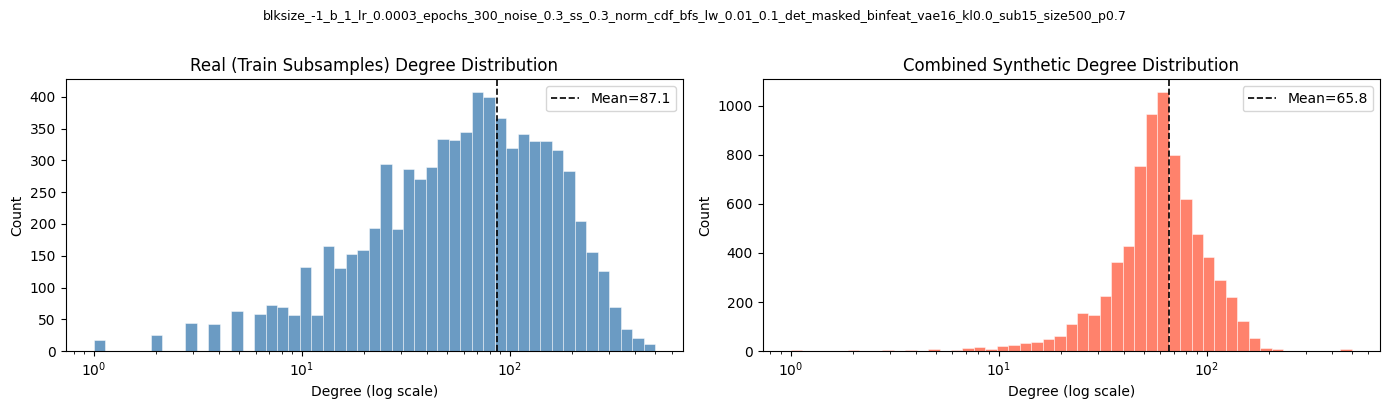

In [31]:
combined_nx = nx.Graph(combined.to_networkx())
comb_degrees = [d for _, d in combined_nx.degree()]

def degree_stats_dict(degrees, label):
    return {
        'Mean': f'{np.mean(degrees):.2f}',
        'Median': f'{np.median(degrees):.1f}',
        'Max': max(degrees),
    }

real_col = 'Real (Train Subsamples)' if COMPARE_AGAINST == 'training_subsamples' else 'Real (Full Original)'
deg_df = pd.DataFrame({
    real_col: degree_stats_dict(real_degrees, 'real'),
    'Combined Synthetic': degree_stats_dict(comb_degrees, 'syn'),
})
print('Degree statistics:')
display(deg_df)

# Degree distribution overlay
max_deg = max(max(real_degrees), max(comb_degrees))
bins = np.logspace(0, np.log10(max_deg + 1), 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, degrees, label, color in zip(
    axes,
    [real_degrees, comb_degrees],
    [real_col, 'Combined Synthetic'],
    ['steelblue', 'tomato'],
):
    ax.hist(degrees, bins=bins, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.set_xscale('log')
    ax.set_xlabel('Degree (log scale)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Degree Distribution')
    ax.axvline(np.mean(degrees), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean={np.mean(degrees):.1f}')
    ax.legend()

plt.suptitle(run, fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

Computing clustering coefficients (may be slow for large graphs)...


,Real (Train Subsamples),Combined Synthetic
Avg clustering coeff,0.5772,0.1949


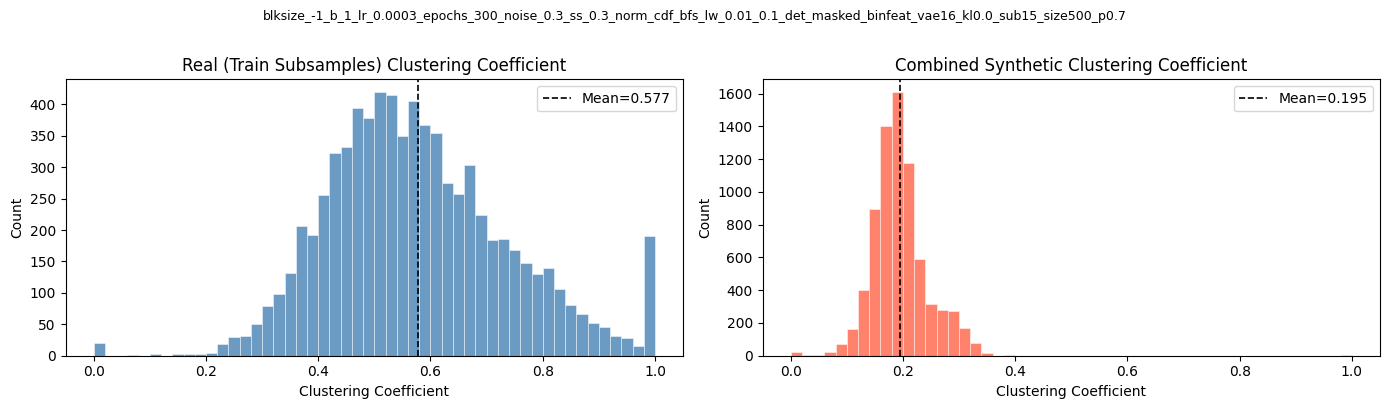

In [32]:
# Clustering coefficient
print('Computing clustering coefficients (may be slow for large graphs)...')

real_cc_avg = nx.average_clustering(real_nx)
comb_cc_avg = nx.average_clustering(combined_nx)

cc_df = pd.DataFrame({
    real_col: {'Avg clustering coeff': f'{real_cc_avg:.4f}'},
    'Combined Synthetic': {'Avg clustering coeff': f'{comb_cc_avg:.4f}'},
})
display(cc_df)

real_cc = list(nx.clustering(real_nx).values())
comb_cc = list(nx.clustering(combined_nx).values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, cc_vals, label, color in zip(
    axes,
    [real_cc, comb_cc],
    [real_col, 'Combined Synthetic'],
    ['steelblue', 'tomato'],
):
    ax.hist(cc_vals, bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Clustering Coefficient')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Clustering Coefficient')
    ax.axvline(np.mean(cc_vals), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean={np.mean(cc_vals):.3f}')
    ax.legend()

plt.suptitle(run, fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

## Feature Distribution — Combined vs Original

Per-feature mean / std (normalised space — 6 binary, 4 continuous):
 Feat  Type |    Real μ  Real σ |     Syn μ   Syn σ
---------------------------------------------------
    0  cont |    0.4878  0.2346 |    0.3903  0.1540
    1  cont |    0.4844  0.4318 |    0.0178  0.0411
    2  cont |    0.3912  0.2278 |    0.0730  0.0774
    3  cont |    0.5281  0.3435 |    0.1430  0.1514
    4   bin |    0.2585  0.4378 |    0.0900  0.2862
    5   bin |    0.0657  0.2478 |    0.1868  0.3898
    6   bin |    0.0388  0.1931 |    0.3761  0.4844
    7   bin |    0.6369  0.4809 |    0.0035  0.0588
    8   bin |    0.9977  0.0476 |    0.6732  0.4690
    9   bin |    0.8921  0.3102 |    0.0043  0.0652


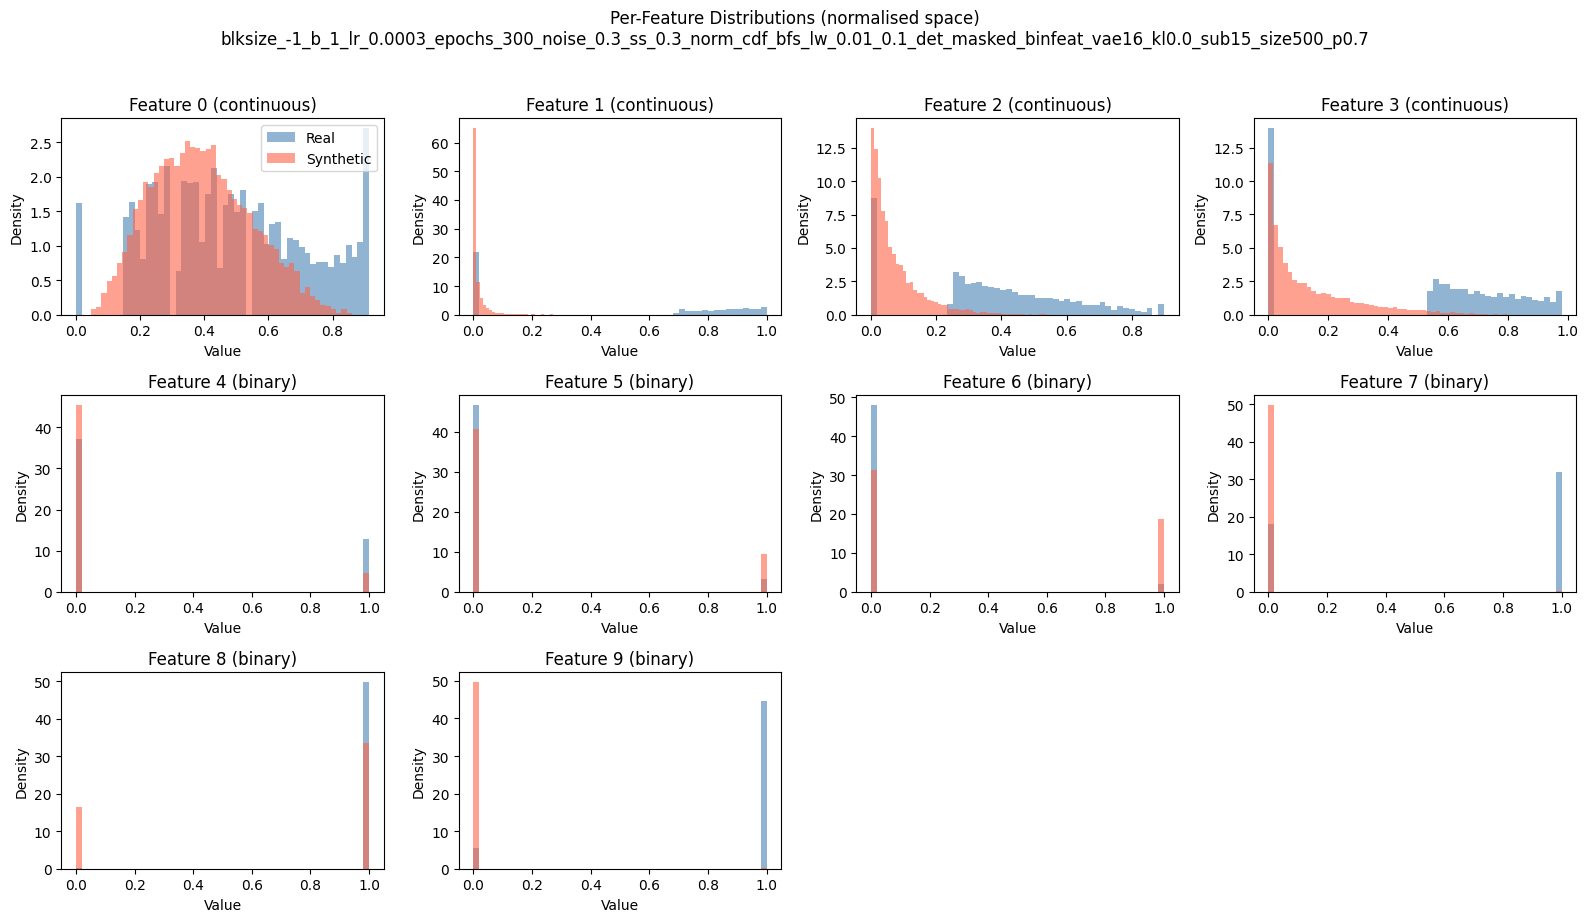

In [33]:
# Normalised space — apply the training-time normalisation to the real features,
# use synthetic as-is (since it was generated in this space).
# Note: when COMPARE_AGAINST='training_subsamples', real_combined is already in
# normalised space (saved that way by pipeline.py), so skip apply_normalization.
import sys
sys.path.insert(0, os.path.abspath('.'))
from bigg.extension.preprocessing import apply_normalization, invert_normalization

real_feats = real_combined.ndata['feature'].numpy()
syn_feats_raw = combined.ndata['feature'].numpy()
feat_dim = real_feats.shape[1]
binary_idx = norm_stats.get('binary_idx', []) if norm_stats is not None else []
cont_idx = sorted(set(range(feat_dim)) - set(binary_idx))

if COMPARE_AGAINST == 'training_subsamples':
    # Training subsamples are already stored in normalised space.
    real_norm = real_feats
else:
    real_norm = real_feats.copy()
    if norm_stats is not None and cont_idx:
        real_norm[:, cont_idx] = apply_normalization(
            torch.tensor(real_feats[:, cont_idx], dtype=torch.float32), norm_stats
        ).numpy()

real_feats_cmp = real_norm
syn_feats_cmp = syn_feats_raw

# Per-feature summary
print(f'Per-feature mean / std (normalised space — {len(binary_idx)} binary, {len(cont_idx)} continuous):')
header = f"{'Feat':>5} {'Type':>5} | {'Real μ':>9} {'Real σ':>7} | {'Syn μ':>9} {'Syn σ':>7}"
print(header); print('-' * len(header))
for i in range(feat_dim):
    t = 'bin' if i in binary_idx else 'cont'
    print(f"{i:>5} {t:>5} | {real_feats_cmp[:, i].mean():>9.4f} {real_feats_cmp[:, i].std():>7.4f} "
          f"| {syn_feats_cmp[:, i].mean():>9.4f} {syn_feats_cmp[:, i].std():>7.4f}")

# Per-feature distributions
ncols = 4
nrows = (feat_dim + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()
for i in range(feat_dim):
    ax = axes[i]
    ax.hist(real_feats_cmp[:, i], bins=50, alpha=0.6, label='Real',      color='steelblue', density=True)
    ax.hist(syn_feats_cmp[:, i],  bins=50, alpha=0.6, label='Synthetic', color='tomato',    density=True)
    t = 'binary' if i in binary_idx else 'continuous'
    ax.set_title(f'Feature {i} ({t})')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    if i == 0:
        ax.legend()
for j in range(feat_dim, len(axes)):
    axes[j].set_visible(False)
plt.suptitle(f'Per-Feature Distributions (normalised space)\n{run}', y=1.02)
plt.tight_layout()
plt.show()


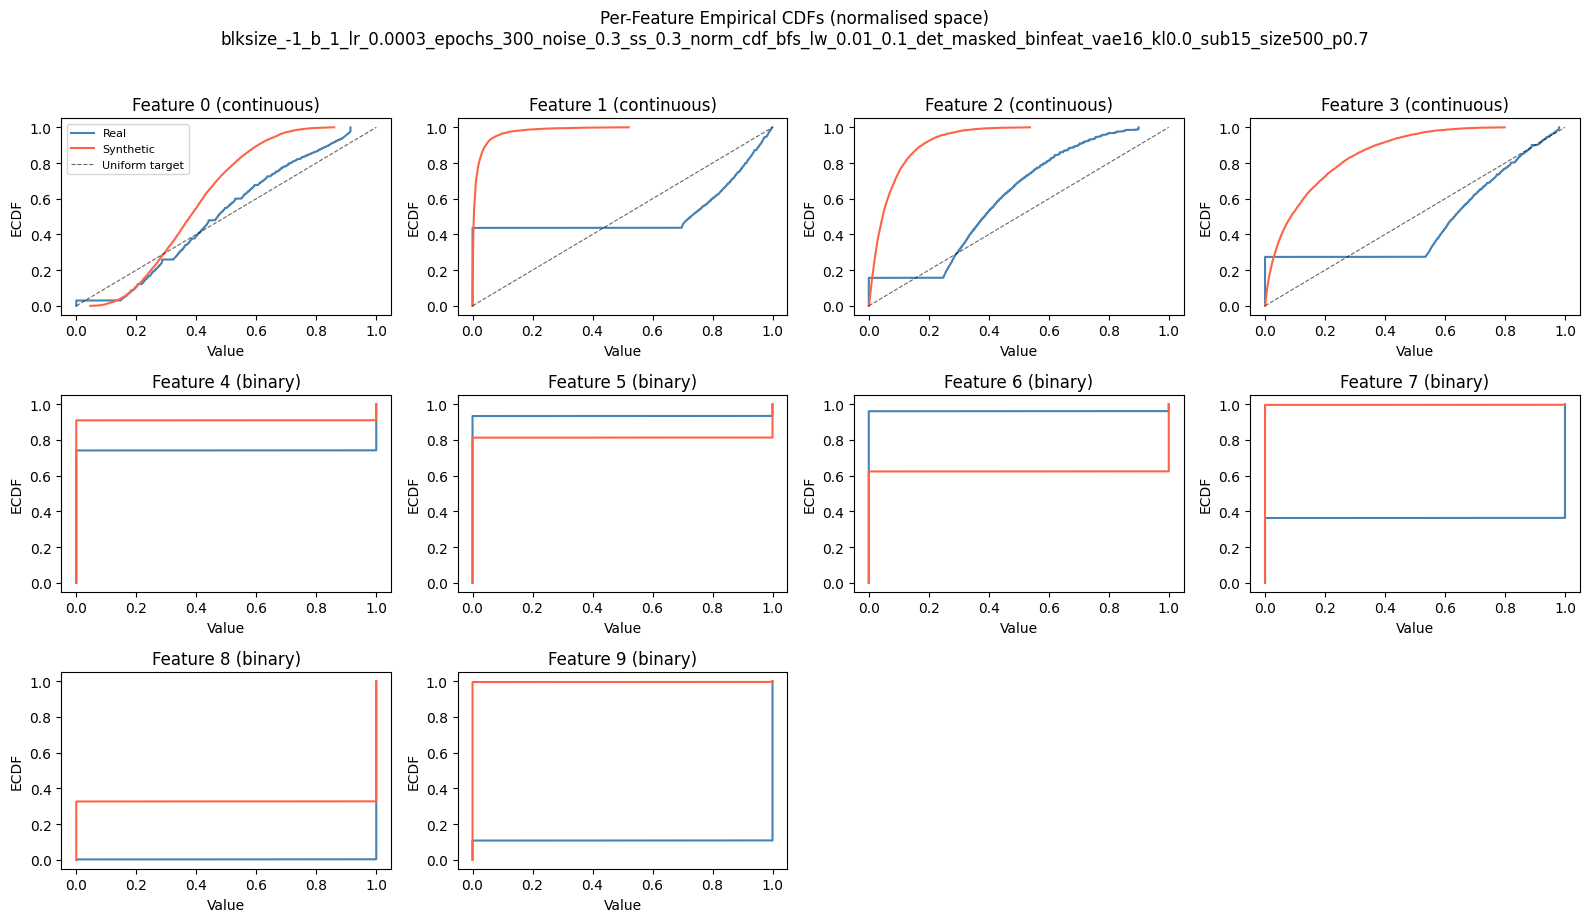

In [34]:
# Empirical CDF view (normalised space).
# For `--normalize cdf`, real features are Uniform[0,1] by construction,
# so the real ECDF should land on the diagonal y = x. Synthetic deviation
# from the diagonal = marginal-fidelity gap (e.g. sigmoid-mean collapse
# toward conditional means under cdf_mode).
# For other normalisations this is just a standard real-vs-syn ECDF overlay.
ncols = 4
nrows = (feat_dim + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

is_cdf = norm_stats is not None and norm_stats.get('method') == 'cdf'

for i in range(feat_dim):
    ax = axes[i]
    r_vals = np.sort(real_feats_cmp[:, i])
    s_vals = np.sort(syn_feats_cmp[:, i])
    r_q = np.linspace(0, 1, len(r_vals), endpoint=False) + 0.5 / len(r_vals)
    s_q = np.linspace(0, 1, len(s_vals), endpoint=False) + 0.5 / len(s_vals)
    ax.plot(r_vals, r_q, color='steelblue', lw=1.5, label='Real')
    ax.plot(s_vals, s_q, color='tomato',    lw=1.5, label='Synthetic')
    if is_cdf and i not in binary_idx:
        ax.plot([0, 1], [0, 1], color='black', lw=0.8, ls='--', alpha=0.6,
                label='Uniform target' if i == 0 else None)
    t = 'binary' if i in binary_idx else 'continuous'
    ax.set_title(f'Feature {i} ({t})')
    ax.set_xlabel('Value'); ax.set_ylabel('ECDF')
    if i == 0:
        ax.legend(fontsize=8)
for j in range(feat_dim, len(axes)):
    axes[j].set_visible(False)
plt.suptitle(f'Per-Feature Empirical CDFs (normalised space)\n{run}', y=1.02)
plt.tight_layout()
plt.show()


Per-feature mean / std (original space — 6 binary, 4 continuous):
 Feat  Type |    Real μ  Real σ |     Syn μ   Syn σ
---------------------------------------------------
    0  cont |    0.6502  0.2540 |    0.5618  0.2085
    1  cont |    0.1227  0.1792 |    0.0000  0.0000
    2  cont |    0.0521  0.1203 |    0.0005  0.0030
    3  cont |    0.1742  0.2298 |    0.0018  0.0148
    4   bin |    0.2585  0.4378 |    0.0900  0.2862
    5   bin |    0.0657  0.2478 |    0.1868  0.3898
    6   bin |    0.0388  0.1931 |    0.3761  0.4844
    7   bin |    0.6369  0.4809 |    0.0035  0.0588
    8   bin |    0.9977  0.0476 |    0.6732  0.4690
    9   bin |    0.8921  0.3102 |    0.0043  0.0652


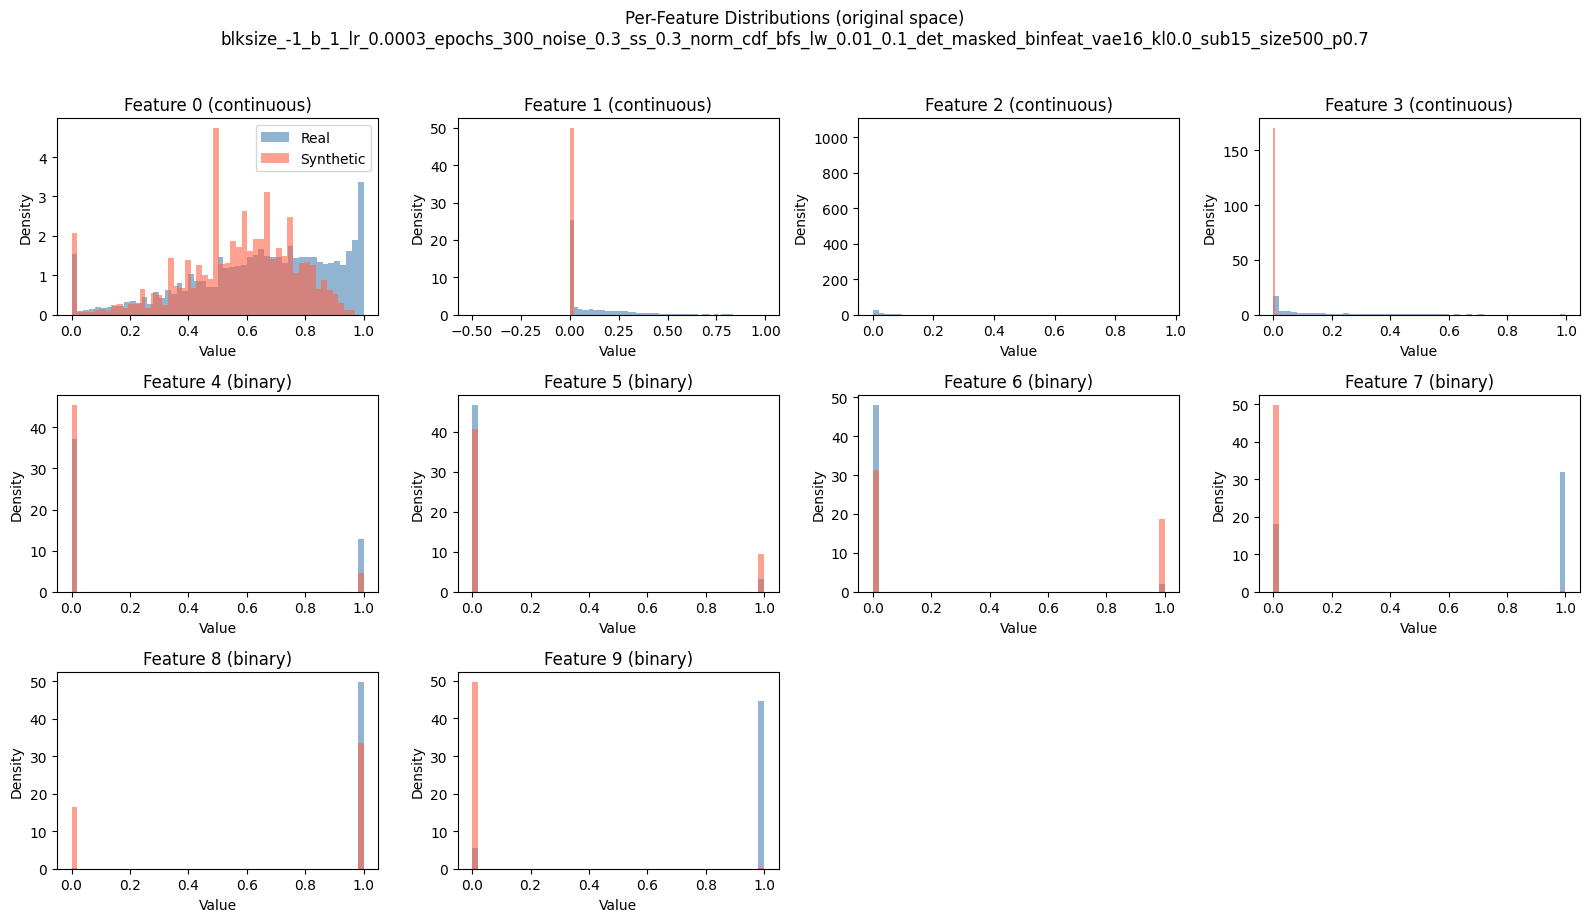

In [35]:
# Original space — invert only the synthetic continuous columns (binary are already 0/1).
# Real features are inverted too if they were stored normalised (training subsamples),
# otherwise they pass through unchanged (full original graph).
real_feats = real_combined.ndata['feature'].numpy()
syn_feats_raw = combined.ndata['feature'].numpy()
feat_dim = real_feats.shape[1]
binary_idx = norm_stats.get('binary_idx', []) if norm_stats is not None else []
cont_idx = sorted(set(range(feat_dim)) - set(binary_idx))

syn_inv = syn_feats_raw.copy()
if norm_stats is not None and cont_idx:
    syn_inv[:, cont_idx] = invert_normalization(
        torch.tensor(syn_feats_raw[:, cont_idx], dtype=torch.float32), norm_stats
    ).numpy()

if COMPARE_AGAINST == 'training_subsamples' and norm_stats is not None and cont_idx:
    real_inv = real_feats.copy()
    real_inv[:, cont_idx] = invert_normalization(
        torch.tensor(real_feats[:, cont_idx], dtype=torch.float32), norm_stats
    ).numpy()
else:
    real_inv = real_feats

real_feats_cmp = real_inv
syn_feats_cmp = syn_inv

print(f'Per-feature mean / std (original space — {len(binary_idx)} binary, {len(cont_idx)} continuous):')
header = f"{'Feat':>5} {'Type':>5} | {'Real μ':>9} {'Real σ':>7} | {'Syn μ':>9} {'Syn σ':>7}"
print(header); print('-' * len(header))
for i in range(feat_dim):
    t = 'bin' if i in binary_idx else 'cont'
    print(f"{i:>5} {t:>5} | {real_feats_cmp[:, i].mean():>9.4f} {real_feats_cmp[:, i].std():>7.4f} "
          f"| {syn_feats_cmp[:, i].mean():>9.4f} {syn_feats_cmp[:, i].std():>7.4f}")

ncols = 4
nrows = (feat_dim + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()
for i in range(feat_dim):
    ax = axes[i]
    ax.hist(real_feats_cmp[:, i], bins=50, alpha=0.6, label='Real',      color='steelblue', density=True)
    ax.hist(syn_feats_cmp[:, i],  bins=50, alpha=0.6, label='Synthetic', color='tomato',    density=True)
    t = 'binary' if i in binary_idx else 'continuous'
    ax.set_title(f'Feature {i} ({t})')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    if i == 0:
        ax.legend()
for j in range(feat_dim, len(axes)):
    axes[j].set_visible(False)
plt.suptitle(f'Per-Feature Distributions (original space)\n{run}', y=1.02)
plt.tight_layout()
plt.show()


## Label-Conditional Feature Distributions

Splits per-feature distributions by node label (normal vs anomaly) on both sides. For each feature:

- **Real Δμ, Real AUC₁** — how much normals and anomalies separate in the real data (univariate anomaly AUROC if you predicted by that feature alone).
- **Syn Δμ, Syn AUC₁** — same on synthetic. Compares whether the decoder preserved the class gap.

**What to look for:** if synthetic Δμ collapses toward 0 while real Δμ is nonzero — or if Syn AUC₁ drops to ~0.5 while Real AUC₁ is > 0.5 — the label→feature signal is being lost at generation. This is the architectural signature of a label-agnostic latent / weak y-conditioning in the feature head, not a marginal-shape issue.

Per-feature label separation (normalized space). AUC₁ = single-feature anomaly AUROC.
Mean |Δμ|         — real: 0.060   syn: 0.050
Mean |AUC₁−0.5|   — real: 0.039   syn: 0.039   (signal retained: 99%)


,Type,Real μ|0,Real μ|1,Real Δμ,Real AUC₁,Syn μ|0,Syn μ|1,Syn Δμ,Syn AUC₁
Feat,,,,,,,,,
0,cont,0.505,0.558,0.053,0.561,0.507,0.609,0.101,0.637
1,cont,0.490,0.506,0.016,0.510,0.420,0.462,0.042,0.537
2,cont,0.407,0.338,-0.069,0.398,0.399,0.368,-0.030,0.459
3,cont,0.445,0.475,0.030,0.499,0.387,0.398,0.012,0.512
4,bin,0.338,0.135,-0.203,0.398,0.392,0.244,-0.147,0.426
5,bin,0.064,0.070,0.006,0.503,0.036,0.042,0.006,0.503
6,bin,0.035,0.043,0.008,0.504,0.008,0.017,0.009,0.505
7,bin,0.563,0.752,0.189,0.595,0.533,0.672,0.139,0.569
8,bin,0.994,0.998,0.004,0.502,0.999,1.000,0.001,0.501


/home/eirik/miniconda3/envs/GADBench/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/home/eirik/miniconda3/envs/GADBench/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/tmp/ipykernel_11661/3698083426.py:74: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo, hi)
/tmp/ipykernel_11661/3698083426.py:82: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo, hi)


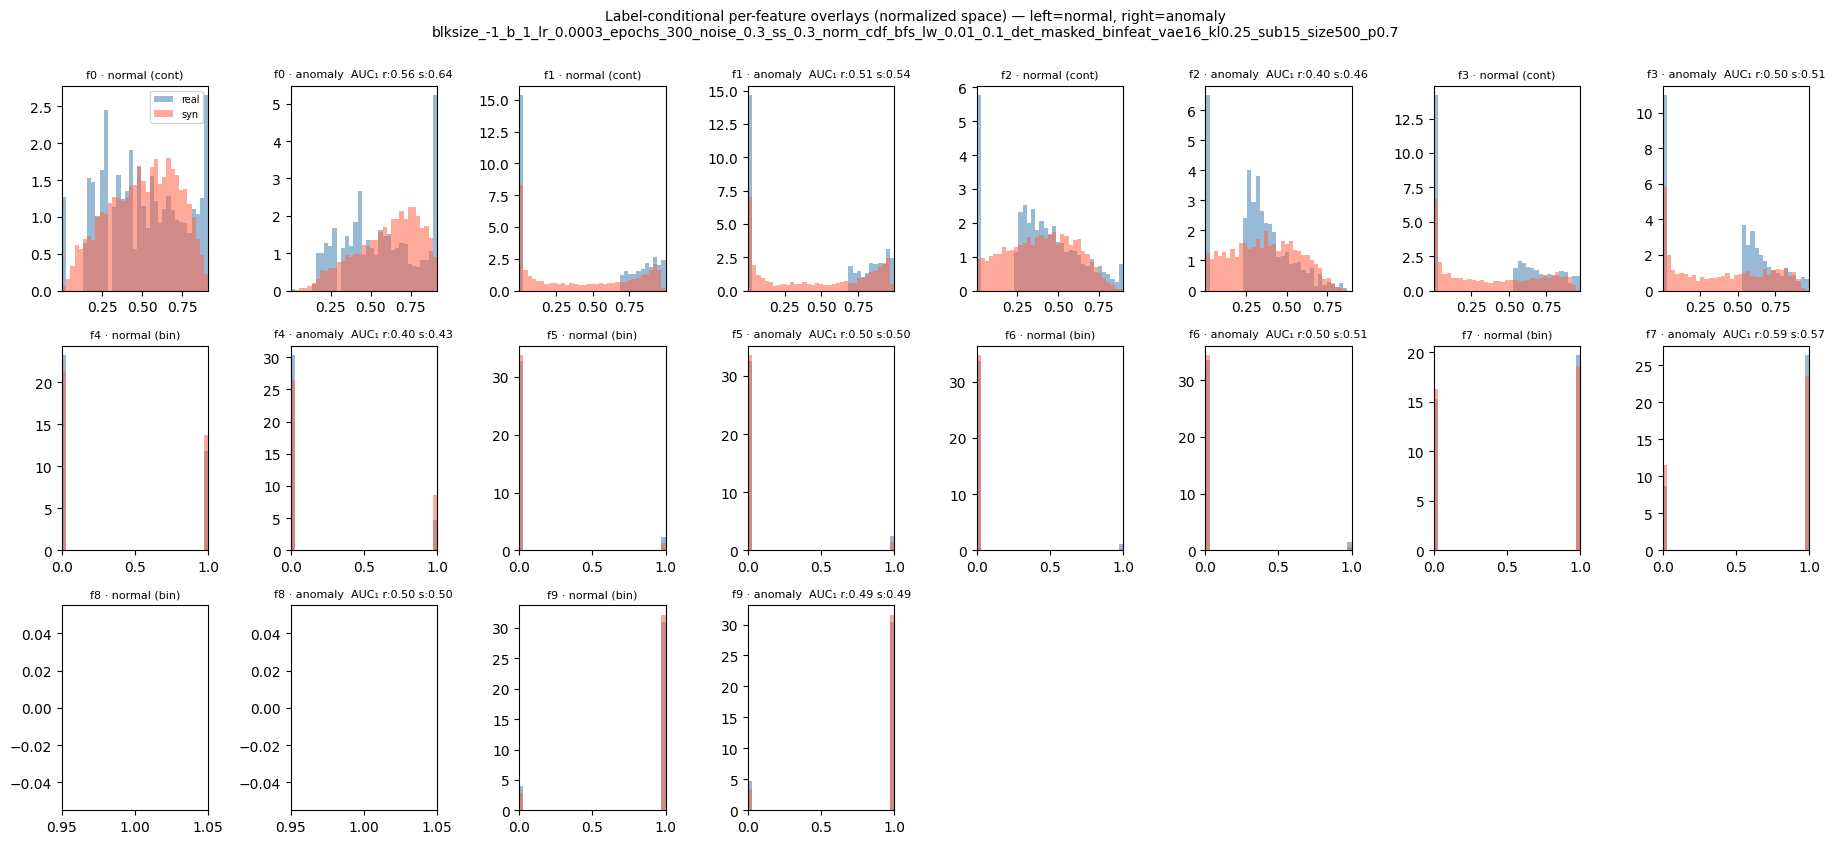

In [11]:
from sklearn.metrics import roc_auc_score

# Work in normalized space (matches where model and benchmark operate).
real_feats_lc = real_combined.ndata['feature'].numpy()
syn_feats_lc = combined.ndata['feature'].numpy()
real_labels = real_combined.ndata['label'].numpy().astype(int)
syn_labels = combined.ndata['label'].numpy().astype(int)
feat_dim = real_feats_lc.shape[1]
binary_idx = norm_stats.get('binary_idx', []) if norm_stats is not None else []
cont_idx = sorted(set(range(feat_dim)) - set(binary_idx))

if COMPARE_AGAINST == 'training_subsamples':
    real_norm_lc = real_feats_lc  # already normalized on disk
else:
    real_norm_lc = real_feats_lc.copy()
    if norm_stats is not None and cont_idx:
        real_norm_lc[:, cont_idx] = apply_normalization(
            torch.tensor(real_feats_lc[:, cont_idx], dtype=torch.float32), norm_stats
        ).numpy()

def _auc(y, s):
    try:
        return roc_auc_score(y, s)
    except ValueError:
        return float('nan')

rows = []
for i in range(feat_dim):
    t = 'bin' if i in binary_idx else 'cont'
    r_norm_mu = real_norm_lc[real_labels == 0, i].mean()
    r_anom_mu = real_norm_lc[real_labels == 1, i].mean()
    s_norm_mu = syn_feats_lc[syn_labels == 0, i].mean()
    s_anom_mu = syn_feats_lc[syn_labels == 1, i].mean()
    rows.append({
        'Feat': i, 'Type': t,
        'Real μ|0': r_norm_mu, 'Real μ|1': r_anom_mu, 'Real Δμ': r_anom_mu - r_norm_mu,
        'Real AUC₁': _auc(real_labels, real_norm_lc[:, i]),
        'Syn μ|0': s_norm_mu, 'Syn μ|1': s_anom_mu, 'Syn Δμ': s_anom_mu - s_norm_mu,
        'Syn AUC₁': _auc(syn_labels, syn_feats_lc[:, i]),
    })

sep_df = pd.DataFrame(rows).set_index('Feat').round(3)
real_disc = (sep_df['Real AUC₁'] - 0.5).abs().mean()
syn_disc = (sep_df['Syn AUC₁'] - 0.5).abs().mean()

print('Per-feature label separation (normalized space). AUC₁ = single-feature anomaly AUROC.')
print(f"Mean |Δμ|         — real: {sep_df['Real Δμ'].abs().mean():.3f}   syn: {sep_df['Syn Δμ'].abs().mean():.3f}")
print(f"Mean |AUC₁−0.5|   — real: {real_disc:.3f}   syn: {syn_disc:.3f}   "
      f"(signal retained: {100*syn_disc/real_disc:.0f}%)")
display(sep_df)

# Paired overlays with SHARED x-axis per feature.
#   Left panel:  real vs syn restricted to NORMAL nodes
#   Right panel: real vs syn restricted to ANOMALY nodes
# This keeps the visual comparison honest (old version used separate real/syn panels
# with independent autoscaling, which masked real shape disagreements).
features_per_row = 4
total_cols = features_per_row * 2
nrows_p = (feat_dim + features_per_row - 1) // features_per_row
fig, axes = plt.subplots(nrows_p, total_cols, figsize=(total_cols * 2.3, nrows_p * 2.8))
axes = np.atleast_2d(axes)

for i in range(feat_dim):
    r, c = i // features_per_row, (i % features_per_row) * 2
    t = 'bin' if i in binary_idx else 'cont'

    vals = np.concatenate([real_norm_lc[:, i], syn_feats_lc[:, i]])
    lo, hi = np.percentile(vals, [0.5, 99.5])
    bins = np.linspace(lo, hi, 36)

    ax = axes[r, c]
    ax.hist(real_norm_lc[real_labels == 0, i], bins=bins, alpha=0.55, color='steelblue', density=True, label='real')
    ax.hist(syn_feats_lc[syn_labels == 0, i],  bins=bins, alpha=0.55, color='tomato',    density=True, label='syn')
    ax.set_xlim(lo, hi)
    ax.set_title(f'f{i} · normal ({t})', fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

    ax = axes[r, c + 1]
    ax.hist(real_norm_lc[real_labels == 1, i], bins=bins, alpha=0.55, color='steelblue', density=True)
    ax.hist(syn_feats_lc[syn_labels == 1, i],  bins=bins, alpha=0.55, color='tomato',    density=True)
    ax.set_xlim(lo, hi)
    ax.set_title(
        f'f{i} · anomaly  AUC₁ r:{sep_df.loc[i, "Real AUC₁"]:.2f} s:{sep_df.loc[i, "Syn AUC₁"]:.2f}',
        fontsize=8,
    )

for r in range(nrows_p):
    for c in range(total_cols):
        idx = r * features_per_row + c // 2
        if idx >= feat_dim:
            axes[r, c].set_visible(False)

plt.suptitle(
    f'Label-conditional per-feature overlays (normalized space) — left=normal, right=anomaly\n{run}',
    y=1.00, fontsize=10,
)
plt.tight_layout()
plt.show()


Per-feature label separation (original space). AUC₁ = single-feature anomaly AUROC.
Mean |Δμ|         — real: 0.056   syn: 0.046
Mean |AUC₁−0.5|   — real: 0.039   syn: 0.037   (signal retained: 95%)


,Type,Real μ|0,Real μ|1,Real Δμ,Real AUC₁,Syn μ|0,Syn μ|1,Syn Δμ,Syn AUC₁
Feat,,,,,,,,,
0,cont,0.662,0.724,0.062,0.561,0.671,0.778,0.107,0.637
1,cont,0.128,0.132,0.004,0.510,0.062,0.077,0.016,0.530
2,cont,0.060,0.027,-0.033,0.398,0.038,0.031,-0.007,0.460
3,cont,0.149,0.117,-0.032,0.499,0.091,0.082,-0.009,0.499
4,bin,0.338,0.135,-0.203,0.398,0.392,0.244,-0.147,0.426
5,bin,0.064,0.070,0.006,0.503,0.036,0.042,0.006,0.503
6,bin,0.035,0.043,0.008,0.504,0.008,0.017,0.009,0.505
7,bin,0.563,0.752,0.189,0.595,0.533,0.672,0.139,0.569
8,bin,0.994,0.998,0.004,0.502,0.999,1.000,0.001,0.501


/home/eirik/miniconda3/envs/GADBench/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/home/eirik/miniconda3/envs/GADBench/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges
/tmp/ipykernel_11661/1267597912.py:66: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo, hi)
/tmp/ipykernel_11661/1267597912.py:74: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(lo, hi)


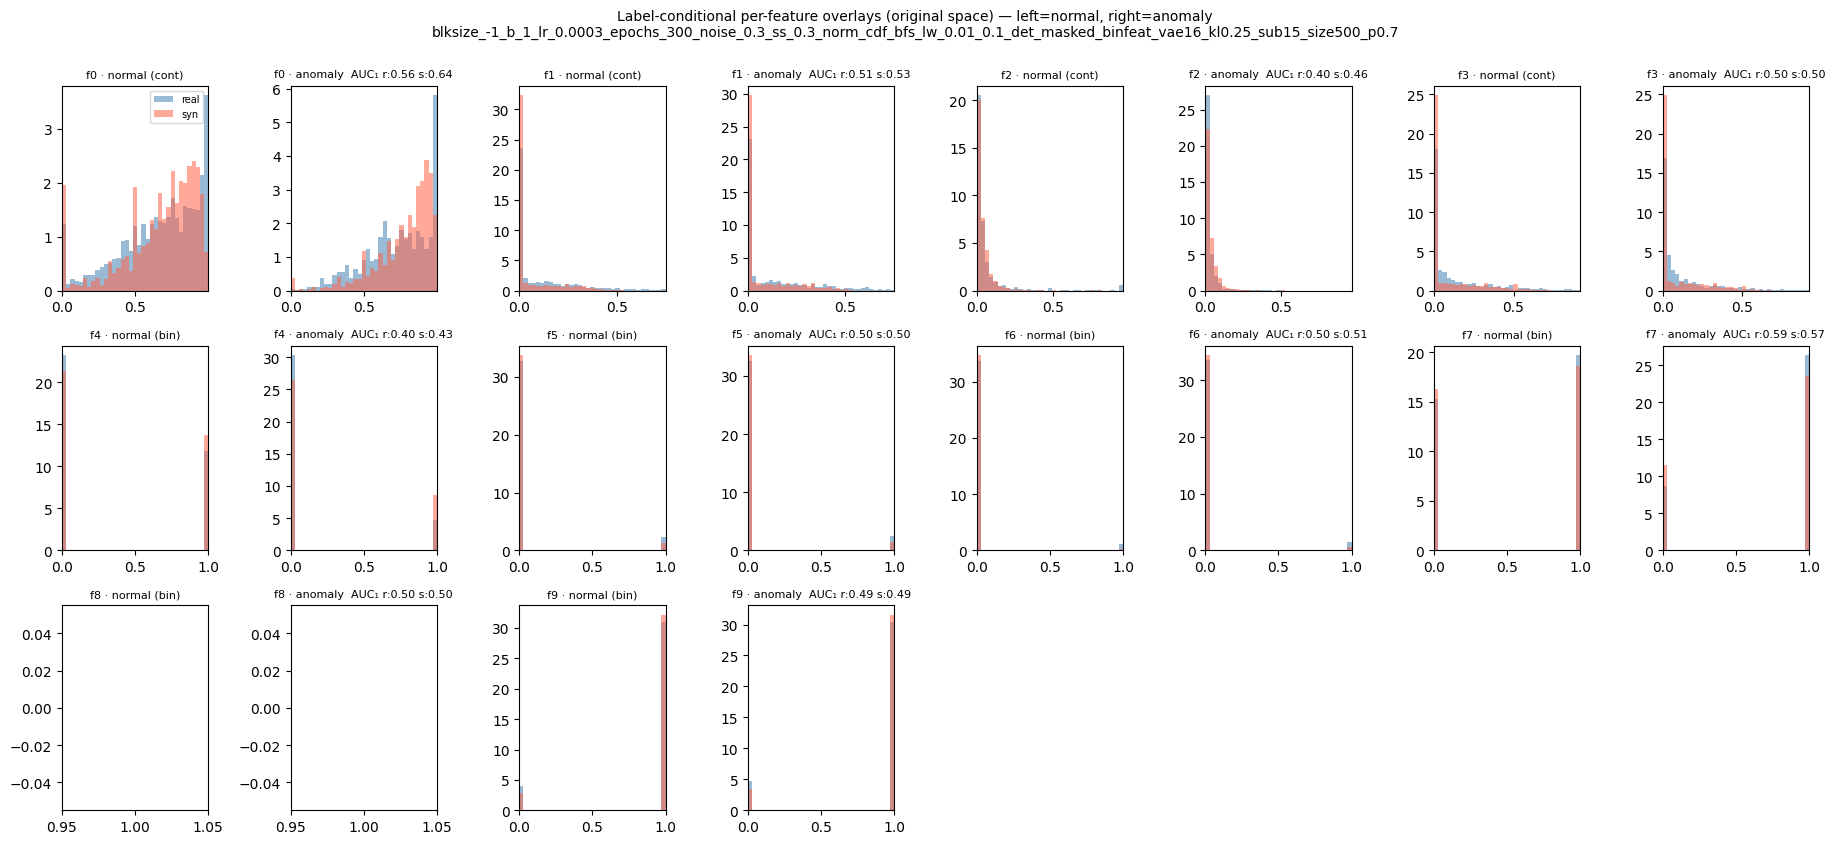

In [12]:
# Same view in ORIGINAL space (continuous features inverted via invert_normalization).
real_feats_lc_o = real_combined.ndata['feature'].numpy()
syn_feats_lc_o = combined.ndata['feature'].numpy()
real_labels = real_combined.ndata['label'].numpy().astype(int)
syn_labels = combined.ndata['label'].numpy().astype(int)
feat_dim = real_feats_lc_o.shape[1]
binary_idx = norm_stats.get('binary_idx', []) if norm_stats is not None else []
cont_idx = sorted(set(range(feat_dim)) - set(binary_idx))

syn_orig_lc = syn_feats_lc_o.copy()
if norm_stats is not None and cont_idx:
    syn_orig_lc[:, cont_idx] = invert_normalization(
        torch.tensor(syn_feats_lc_o[:, cont_idx], dtype=torch.float32), norm_stats
    ).numpy()

if COMPARE_AGAINST == 'training_subsamples' and norm_stats is not None and cont_idx:
    real_orig_lc = real_feats_lc_o.copy()
    real_orig_lc[:, cont_idx] = invert_normalization(
        torch.tensor(real_feats_lc_o[:, cont_idx], dtype=torch.float32), norm_stats
    ).numpy()
else:
    real_orig_lc = real_feats_lc_o

rows_o = []
for i in range(feat_dim):
    t = 'bin' if i in binary_idx else 'cont'
    r_norm_mu = real_orig_lc[real_labels == 0, i].mean()
    r_anom_mu = real_orig_lc[real_labels == 1, i].mean()
    s_norm_mu = syn_orig_lc[syn_labels == 0, i].mean()
    s_anom_mu = syn_orig_lc[syn_labels == 1, i].mean()
    rows_o.append({
        'Feat': i, 'Type': t,
        'Real μ|0': r_norm_mu, 'Real μ|1': r_anom_mu, 'Real Δμ': r_anom_mu - r_norm_mu,
        'Real AUC₁': _auc(real_labels, real_orig_lc[:, i]),
        'Syn μ|0': s_norm_mu, 'Syn μ|1': s_anom_mu, 'Syn Δμ': s_anom_mu - s_norm_mu,
        'Syn AUC₁': _auc(syn_labels, syn_orig_lc[:, i]),
    })

sep_df_o = pd.DataFrame(rows_o).set_index('Feat').round(3)
real_disc_o = (sep_df_o['Real AUC₁'] - 0.5).abs().mean()
syn_disc_o = (sep_df_o['Syn AUC₁'] - 0.5).abs().mean()

print('Per-feature label separation (original space). AUC₁ = single-feature anomaly AUROC.')
print(f"Mean |Δμ|         — real: {sep_df_o['Real Δμ'].abs().mean():.3f}   syn: {sep_df_o['Syn Δμ'].abs().mean():.3f}")
print(f"Mean |AUC₁−0.5|   — real: {real_disc_o:.3f}   syn: {syn_disc_o:.3f}   "
      f"(signal retained: {100*syn_disc_o/real_disc_o:.0f}%)")
display(sep_df_o)

features_per_row = 4
total_cols = features_per_row * 2
nrows_p = (feat_dim + features_per_row - 1) // features_per_row
fig, axes = plt.subplots(nrows_p, total_cols, figsize=(total_cols * 2.3, nrows_p * 2.8))
axes = np.atleast_2d(axes)

for i in range(feat_dim):
    r, c = i // features_per_row, (i % features_per_row) * 2
    t = 'bin' if i in binary_idx else 'cont'

    vals = np.concatenate([real_orig_lc[:, i], syn_orig_lc[:, i]])
    lo, hi = np.percentile(vals, [0.5, 99.5])
    bins = np.linspace(lo, hi, 36)

    ax = axes[r, c]
    ax.hist(real_orig_lc[real_labels == 0, i], bins=bins, alpha=0.55, color='steelblue', density=True, label='real')
    ax.hist(syn_orig_lc[syn_labels == 0, i],   bins=bins, alpha=0.55, color='tomato',    density=True, label='syn')
    ax.set_xlim(lo, hi)
    ax.set_title(f'f{i} · normal ({t})', fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

    ax = axes[r, c + 1]
    ax.hist(real_orig_lc[real_labels == 1, i], bins=bins, alpha=0.55, color='steelblue', density=True)
    ax.hist(syn_orig_lc[syn_labels == 1, i],   bins=bins, alpha=0.55, color='tomato',    density=True)
    ax.set_xlim(lo, hi)
    ax.set_title(
        f'f{i} · anomaly  AUC₁ r:{sep_df_o.loc[i, "Real AUC₁"]:.2f} s:{sep_df_o.loc[i, "Syn AUC₁"]:.2f}',
        fontsize=8,
    )

for r in range(nrows_p):
    for c in range(total_cols):
        idx = r * features_per_row + c // 2
        if idx >= feat_dim:
            axes[r, c].set_visible(False)

plt.suptitle(
    f'Label-conditional per-feature overlays (original space) — left=normal, right=anomaly\n{run}',
    y=1.00, fontsize=10,
)
plt.tight_layout()
plt.show()

## Feature Correlation — Real vs Synthetic

Marginal distributions can match while feature *covariance* collapses. Each head in the current decoder predicts independently from the same hidden state `h` with no shared stochastic latent, so off-diagonal correlations are expected to be the weak link. Side-by-side heatmaps + mean absolute correlation error make the gap explicit.

Off-diagonal correlation MAE (real vs syn): 0.0563
Largest single-pair error: |Δ|=0.2193 at features (5, 7)  (real=-0.342, syn=-0.123)


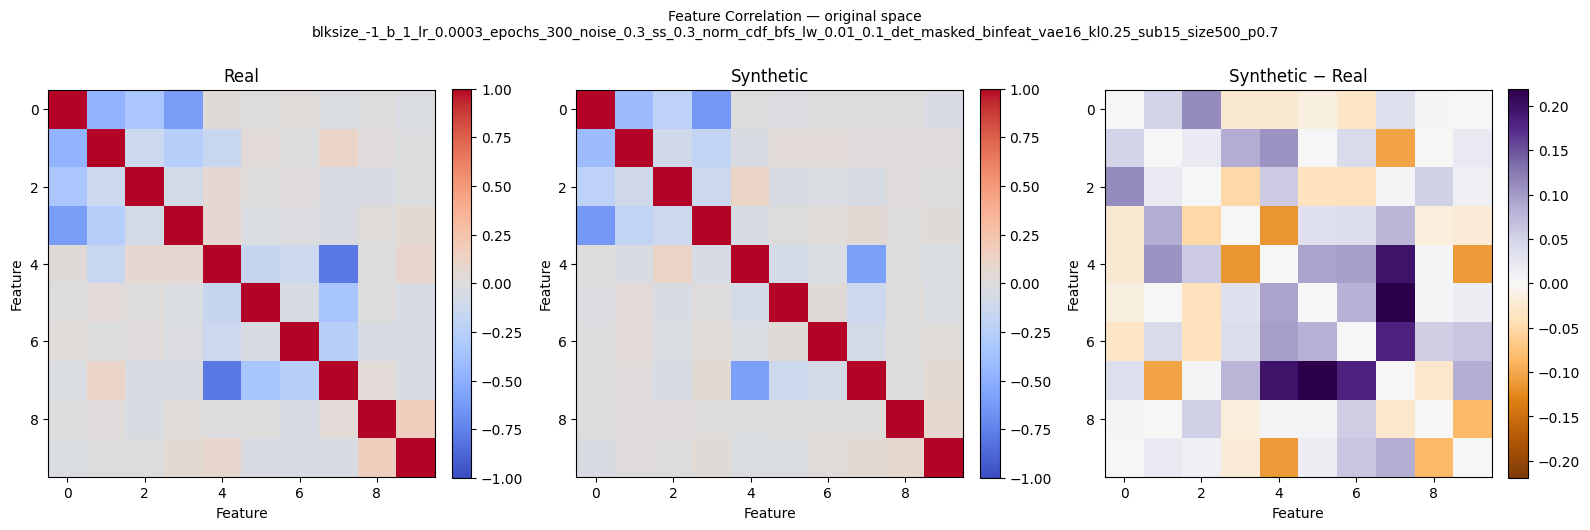


Top-10 off-diagonal correlation disagreements:


,i,j,real,syn,Δ (syn−real)
0,5,7,-0.342,-0.123,0.219
1,4,7,-0.789,-0.592,0.197
2,6,7,-0.253,-0.072,0.181
3,3,4,0.063,-0.054,-0.116
4,0,2,-0.328,-0.216,0.112
5,4,9,0.086,-0.025,-0.111
6,1,4,-0.142,-0.037,0.105
7,1,7,0.115,0.012,-0.104
8,4,6,-0.121,-0.024,0.097
9,4,5,-0.163,-0.069,0.094


In [13]:
# Pearson correlation matrices on the original-space features computed above.
real_corr = np.corrcoef(real_feats_cmp, rowvar=False)
syn_corr  = np.corrcoef(syn_feats_cmp,  rowvar=False)
diff = syn_corr - real_corr

iu = np.triu_indices(feat_dim, k=1)
abs_err = np.abs(diff[iu])
mae_corr = abs_err.mean()
max_err = abs_err.max()
max_pair = np.unravel_index(np.argmax(np.abs(diff) - np.eye(feat_dim) * 1e9), diff.shape)

print(f'Off-diagonal correlation MAE (real vs syn): {mae_corr:.4f}')
print(f'Largest single-pair error: |Δ|={max_err:.4f} at features {max_pair}  '
      f'(real={real_corr[max_pair]:+.3f}, syn={syn_corr[max_pair]:+.3f})')

vmax = max(np.abs(real_corr).max(), np.abs(syn_corr).max())
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, mat, title, cmap, vlim in [
    (axes[0], real_corr, 'Real',           'coolwarm', vmax),
    (axes[1], syn_corr,  'Synthetic',      'coolwarm', vmax),
    (axes[2], diff,      'Synthetic − Real', 'PuOr',  np.abs(diff).max()),
]:
    im = ax.imshow(mat, cmap=cmap, vmin=-vlim, vmax=vlim)
    ax.set_title(title)
    ax.set_xlabel('Feature'); ax.set_ylabel('Feature')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f'Feature Correlation — original space\n{run}', y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

# Top off-diagonal disagreements
pairs = [(i, j, real_corr[i, j], syn_corr[i, j], syn_corr[i, j] - real_corr[i, j])
         for i, j in zip(*iu)]
pairs.sort(key=lambda t: abs(t[4]), reverse=True)
top = pd.DataFrame(pairs[:10], columns=['i', 'j', 'real', 'syn', 'Δ (syn−real)'])
print('\nTop-10 off-diagonal correlation disagreements:')
display(top.round(3))


--- Normal (y=0) (real n=5132, syn n=5706) ---
Off-diagonal correlation MAE: 0.0600
Largest error: |Δ|=0.2144 at features (4, 7)  (real=-0.811, syn=-0.596)


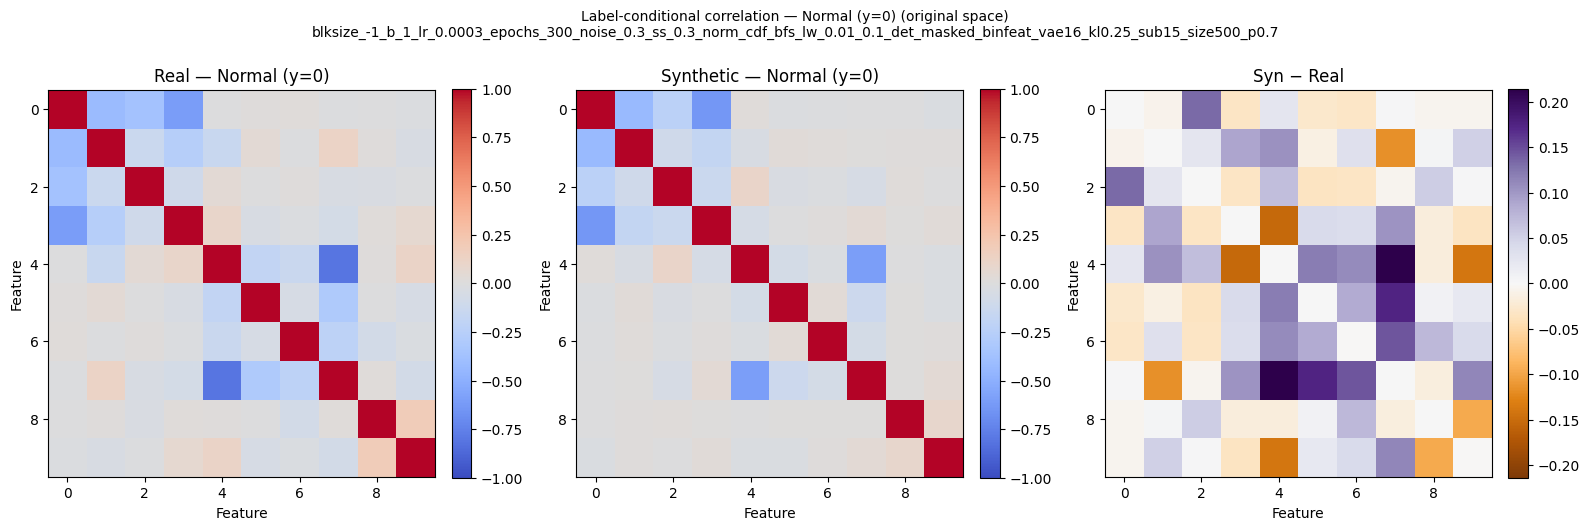

Top-10 off-diagonal correlation disagreements (Normal (y=0)):


,i,j,real,syn,Δ (syn−real)
0,4,7,-0.811,-0.596,0.214
1,5,7,-0.298,-0.123,0.175
2,3,4,0.098,-0.056,-0.154
3,6,7,-0.216,-0.070,0.146
4,4,9,0.110,-0.031,-0.141
5,0,2,-0.360,-0.227,0.133
6,4,5,-0.187,-0.067,0.120
7,1,7,0.121,0.005,-0.116
8,7,9,-0.071,0.042,0.113
9,4,6,-0.136,-0.025,0.110



--- Anomaly (y=1) (real n=2368, syn n=1794) ---
Off-diagonal correlation MAE: nan
Largest error: |Δ|=nan at features (0, 8)  (real=-0.047, syn=+nan)


/home/eirik/miniconda3/envs/GADBench/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/eirik/miniconda3/envs/GADBench/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


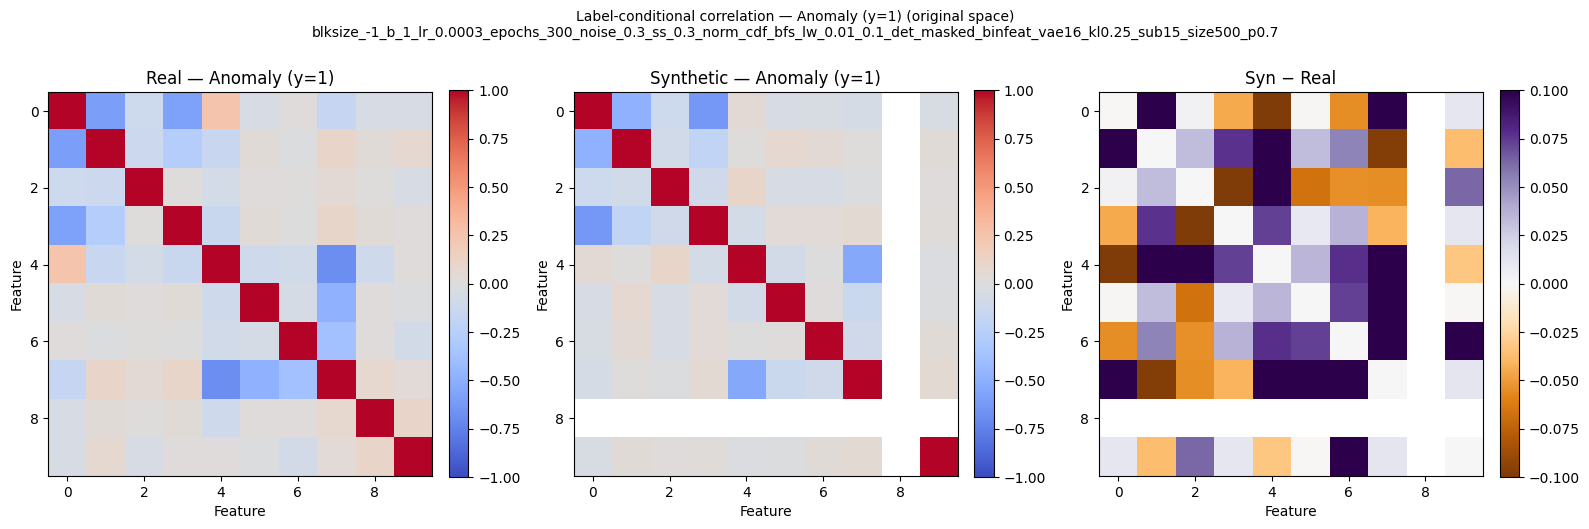

Top-10 off-diagonal correlation disagreements (Anomaly (y=1)):


,i,j,real,syn,Δ (syn−real)
0,0,4,0.247,0.046,-0.202
1,0,8,-0.047,NaN,NaN
2,1,8,0.029,NaN,NaN
3,2,8,0.002,NaN,NaN
4,3,8,0.027,NaN,NaN
5,4,7,-0.687,-0.545,0.142
6,2,5,0.015,-0.052,-0.067
7,4,8,-0.104,NaN,NaN
8,5,7,-0.478,-0.133,0.346
9,2,4,-0.065,0.099,0.164


In [14]:
# Label-conditional correlation: split by y=0 (normal) and y=1 (anomaly),
# then compare real vs synthetic within each class.
real_labels_corr = real_combined.ndata["label"].numpy().astype(int)
syn_labels_corr = combined.ndata["label"].numpy().astype(int)

for lbl, lbl_name in [(0, "Normal (y=0)"), (1, "Anomaly (y=1)")]:
    real_sub = real_feats_cmp[real_labels_corr == lbl]
    syn_sub = syn_feats_cmp[syn_labels_corr == lbl]

    rc = np.corrcoef(real_sub, rowvar=False)
    sc = np.corrcoef(syn_sub, rowvar=False)
    diff_lc = sc - rc

    iu = np.triu_indices(feat_dim, k=1)
    abs_err = np.abs(diff_lc[iu])
    mae = abs_err.mean()
    max_err = abs_err.max()
    max_pair = np.unravel_index(np.argmax(np.abs(diff_lc) - np.eye(feat_dim) * 1e9), diff_lc.shape)

    print(f"\n--- {lbl_name} (real n={real_sub.shape[0]}, syn n={syn_sub.shape[0]}) ---")
    print(f"Off-diagonal correlation MAE: {mae:.4f}")
    print(f"Largest error: |Δ|={max_err:.4f} at features {max_pair}  "
          f"(real={rc[max_pair]:+.3f}, syn={sc[max_pair]:+.3f})")

    vmax = max(np.abs(rc).max(), np.abs(sc).max())
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, mat, title, cmap, vlim in [
        (axes[0], rc,      f"Real — {lbl_name}",      "coolwarm", vmax),
        (axes[1], sc,      f"Synthetic — {lbl_name}",  "coolwarm", vmax),
        (axes[2], diff_lc, f"Syn − Real",              "PuOr",    np.abs(diff_lc).max()),
    ]:
        im = ax.imshow(mat, cmap=cmap, vmin=-vlim, vmax=vlim)
        ax.set_title(title)
        ax.set_xlabel("Feature"); ax.set_ylabel("Feature")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f"Label-conditional correlation — {lbl_name} (original space)\n{run}", y=1.02, fontsize=10)
    plt.tight_layout()
    plt.show()

    pairs = [(i, j, rc[i, j], sc[i, j], sc[i, j] - rc[i, j])
             for i, j in zip(*iu)]
    pairs.sort(key=lambda t: abs(t[4]), reverse=True)
    top = pd.DataFrame(pairs[:10], columns=["i", "j", "real", "syn", "Δ (syn−real)"])
    print(f"Top-10 off-diagonal correlation disagreements ({lbl_name}):")
    display(top.round(3))


/home/eirik/miniconda3/envs/GADBench/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/eirik/miniconda3/envs/GADBench/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Real correlation shift MAE (|Δρ|):  0.0745
Syn  correlation shift MAE (|Δρ|):  nan
Shift disagreement MAE (|syn_shift - real_shift|): nan


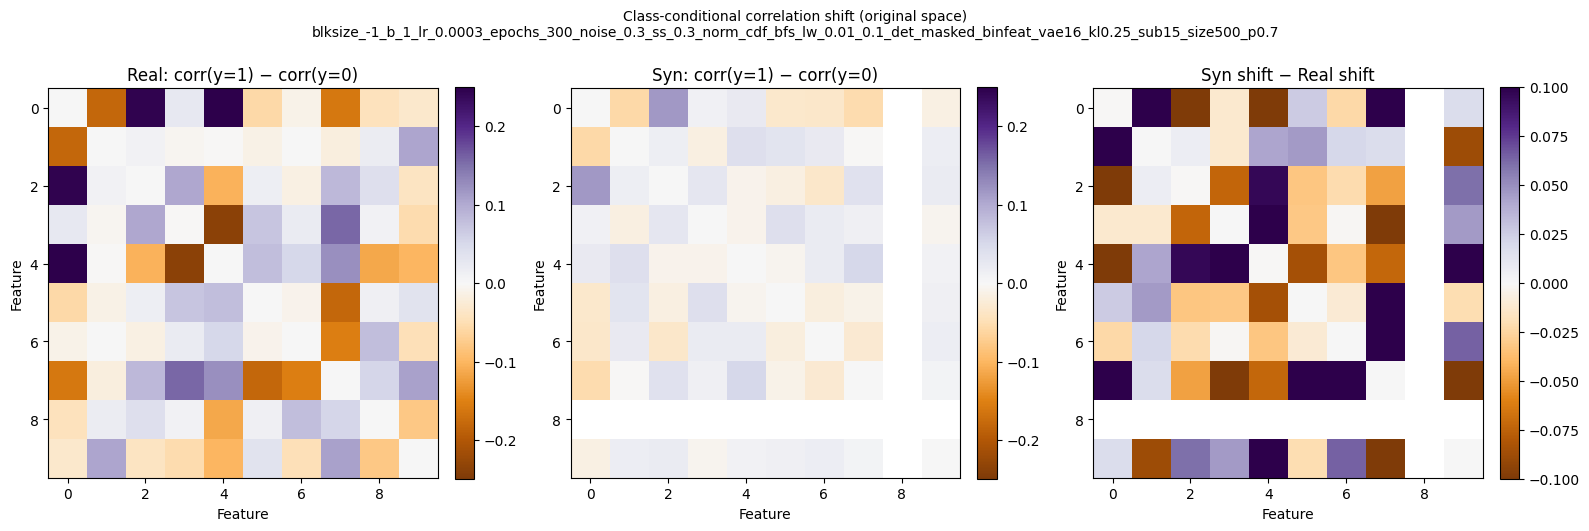


Top-10 pairs where synthetic misses the class-conditional correlation shift:


,i,j,real shift,syn shift,Δ shift
0,0,4,0.250,0.022,-0.227
1,0,8,-0.045,NaN,NaN
2,1,8,0.019,NaN,NaN
3,2,8,0.041,NaN,NaN
4,3,4,-0.236,-0.009,0.227
5,3,7,0.157,0.013,-0.144
6,0,2,0.244,0.115,-0.129
7,0,1,-0.181,-0.058,0.123
8,3,8,0.008,NaN,NaN
9,4,8,-0.114,NaN,NaN


In [15]:
# Class-conditional correlation SHIFT: does synthetic preserve how correlations
# change between normal and anomaly nodes?
# Real shift = corr(real|y=1) - corr(real|y=0)
# Syn shift  = corr(syn|y=1)  - corr(syn|y=0)
# If these match, the generator captures class-dependent feature structure.
real_corr_0 = np.corrcoef(real_feats_cmp[real_labels_corr == 0], rowvar=False)
real_corr_1 = np.corrcoef(real_feats_cmp[real_labels_corr == 1], rowvar=False)
syn_corr_0 = np.corrcoef(syn_feats_cmp[syn_labels_corr == 0], rowvar=False)
syn_corr_1 = np.corrcoef(syn_feats_cmp[syn_labels_corr == 1], rowvar=False)

real_shift = real_corr_1 - real_corr_0
syn_shift = syn_corr_1 - syn_corr_0
shift_diff = syn_shift - real_shift

iu = np.triu_indices(feat_dim, k=1)
print(f"Real correlation shift MAE (|Δρ|):  {np.abs(real_shift[iu]).mean():.4f}")
print(f"Syn  correlation shift MAE (|Δρ|):  {np.abs(syn_shift[iu]).mean():.4f}")
print(f"Shift disagreement MAE (|syn_shift - real_shift|): {np.abs(shift_diff[iu]).mean():.4f}")

vmax_shift = max(np.abs(real_shift).max(), np.abs(syn_shift).max())
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, mat, title, cmap, vlim in [
    (axes[0], real_shift, "Real: corr(y=1) − corr(y=0)",  "PuOr", vmax_shift),
    (axes[1], syn_shift,  "Syn: corr(y=1) − corr(y=0)",   "PuOr", vmax_shift),
    (axes[2], shift_diff, "Syn shift − Real shift",        "PuOr", np.abs(shift_diff).max()),
]:
    im = ax.imshow(mat, cmap=cmap, vmin=-vlim, vmax=vlim)
    ax.set_title(title)
    ax.set_xlabel("Feature"); ax.set_ylabel("Feature")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Class-conditional correlation shift (original space)\n{run}", y=1.02, fontsize=10)
plt.tight_layout()
plt.show()

pairs = [(i, j, real_shift[i, j], syn_shift[i, j], shift_diff[i, j])
         for i, j in zip(*iu)]
pairs.sort(key=lambda t: abs(t[4]), reverse=True)
top = pd.DataFrame(pairs[:10], columns=["i", "j", "real shift", "syn shift", "Δ shift"])
print("\nTop-10 pairs where synthetic misses the class-conditional correlation shift:")
display(top.round(3))


## Subgraph Connectivity Check

Verifies that each synthetic subgraph is connected (or near-connected). Isolated nodes would indicate BFS expansion failed to reach all sampled nodes.

In [16]:
rows = []
for i, sg in enumerate(subgraphs):
    sg_nx = nx.Graph(sg.to_networkx())
    n_components = nx.number_connected_components(sg_nx)
    largest_cc = max(nx.connected_components(sg_nx), key=len)
    zero_deg = sum(1 for _, d in sg_nx.degree() if d == 0)
    rows.append({
        'Subgraph': f'subgraph_{i}',
        'Connected components': n_components,
        'Largest CC (nodes)': len(largest_cc),
        'Isolated nodes (deg=0)': zero_deg,
        'Status': 'OK' if n_components == 1 else f'FRAGMENTED ({n_components} components)',
    })

display(pd.DataFrame(rows).set_index('Subgraph'))

,Connected components,Largest CC (nodes),Isolated nodes (deg=0),Status
Subgraph,,,,
subgraph_0,1,500,0,OK
subgraph_1,1,500,0,OK
subgraph_2,1,500,0,OK
subgraph_3,1,500,0,OK
subgraph_4,1,500,0,OK
subgraph_5,1,500,0,OK
subgraph_6,1,500,0,OK
subgraph_7,1,500,0,OK
subgraph_8,1,500,0,OK
